# Tutorial for GRB170817A parameter estimation with $\tt{bajes}$

This tutorial will show how to perform the analysis for a GRB afterglow event, using as an example GRB170817A.

## Injection

It is also possible to generate some injected data using $\tt{afterglowpy}$. 

For this example we choose a Gaussian jet with these input values:

- $\theta_{obs} = 0.3631$, 
- $E_0 = 10^{54.35}$,
- $\theta_C = 0.0611$,
- $n_0 = 10^{-1.75}$,
- $p = 2.1223$,
- $\epsilon_e = 10^{-3.43}$,
- $\epsilon_B = 10^{-4.02}$,
- $\xi_N = 1$,
- $z = 0.0096$,
- $d_L = 1.234\times 10^{26}$,
- $\theta_W = 0.4363$, 

and this set of bands:  [S, C, v, X-ray-1keV].

https://arxiv.org/abs/2310.02328

[None, Text(0.5, 0, '$t$ (d)'), None, Text(0, 0.5, '$F_\\nu$ (mJy)')]

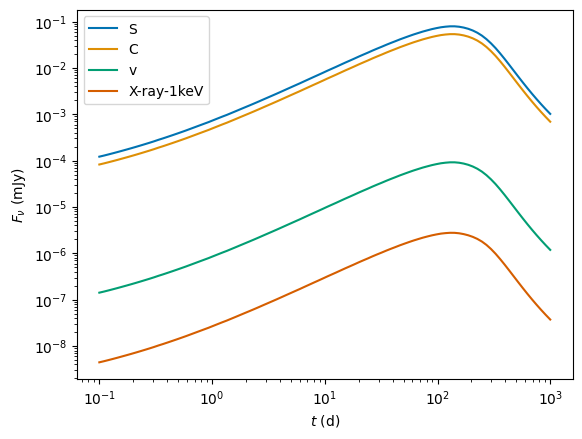

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import afterglowpy as grb
import seaborn as sns
palette = sns.color_palette('colorblind')

GRB170817A = {
     'jetType':     grb.jet.Gaussian,   # Jet type: TopHat, Gaussian, PowerLaw
     'specType':    grb.jet.SimpleSpec, # Basic Synchrotron Emission Spectrum

     'thetaObs':    0.3631,             # Viewing angle in radians
     'E0':          10**(54.35),        # Isotropic-equivalent energy in erg
     'thetaCore':   0.0611,             # Half-opening angle in radians
     'n0':          10**(-1.75),        # circumburst density in cm^{-3}
     'p':           2.1223,             # electron energy distribution index
     'epsilon_e':   10**(-3.42),        # epsilon_e
     'epsilon_B':   10**(-4.02),        # epsilon_B
     'xi_N':        10**(-0.47),        # Fraction of electrons accelerated
     'z':           0.0096,             # reshift
     'd_L':         1.234e26,           # luminosity distance -- 40 Mpc
     'thetaWing':   0.4363,             # wing truncation angle of a structured jet
    }

band    = ['S', 'C', 'v', 'X-ray-1keV']
nu      = [3e9, 6e9, 5.08e14, 2.42e17]

figure = plt.figure()

ta = 0.1
tb = 1e3
t = np.geomspace(ta, tb, num=100)
tsec = t * grb.day2sec

for n,i in zip(nu, range(0,len(nu))):
    Fnu = grb.fluxDensity(tsec, nu[i], **GRB170817A)
    mag = -2.5 * np.log10(Fnu/1e26) - 48.6
    sigma = np.ones(len(mag)) * 0.1
    plt.plot(t, Fnu, color = palette[i], label=band[i])
    # Write to a file
    with open('./injection/' +str(band[i]) + ".txt", 'w') as f:
        f.write("# time \t mag \t sigma \n")
        for i in range(len(t)):
            f.write("{0:.6e} {1:.6e} {2:.6e}\n".format(tsec[i], mag[i], sigma[i]))
plt.legend()
plt.gca().set(xscale='log',
       xlabel=r'$t$ (d)',
       yscale='log',
       ylabel=r'$F_\nu$ (mJy)'
       )

In this way we have data (time, magnitude and standard deviation) in a format readable from $\tt{bajes}$. 

## Inference

The inference can be started with two commands.

Setup command:

`bajes_setup -o ./run --tag grb --mag-folder-grb ./injection --grb-approx grb_afterglow --grb-model Gaussian --theta-obs-min 0. --theta-obs-max 1.57 --theta-core-min 0.02 --theta-core-max 0.78 --e0-min 50 --e0-max 55 --epsilone-min -5 --epsilone-max 0 --epsilonB-min -5 --epsilonB-max 0 --p-min 2 --p-max 3 --n0-min -10 --n0-max 1 --xin-min 0 --xin-max 1 --grb-band X-ray-1keV --grb-band C --grb-band S --grb-band v --fix-name z --fix-value 0.0096 --fix-name xi_N --fix-value 1 --dist-min 10 --dist-max 70`

Inference command:

`python -m bajes -o ./run -I ./run/inf.pkl --checkpoint 1000 --engine dynesty --nlive 5000 --maxmcmc 15000`

In [ ]:
from bajes.pipe import execute_bash

setup_command = "bajes_setup -o ./run --tag grb --mag-folder-grb ./injection --grb-approx grb_afterglow --grb-model Gaussian --theta-obs-min 0. --theta-obs-max 1.57 --theta-core-min 0.02 --theta-core-max 0.78 --e0-min 50 --e0-max 55 --epsilone-min -5 --epsilone-max 0 --epsilonB-min -5 --epsilonB-max 0 --p-min 2 --p-max 3 --n0-min -10 --n0-max 1 --xin-min 0 --xin-max 1 --grb-band X-ray-1keV --grb-band C --grb-band S --grb-band v --fix-name z --fix-value 0.0096 --fix-name xi_N --fix-value 1 --dist-min 10 --dist-max 70" 
execute_bash(setup_command)

inf_command = "python -m bajes -o ./run -I ./run/inf.pkl --checkpoint 1000 --engine dynesty --nlive 5000 --maxmcmc 15000"
execute_bash(inf_command)

## Postprocess

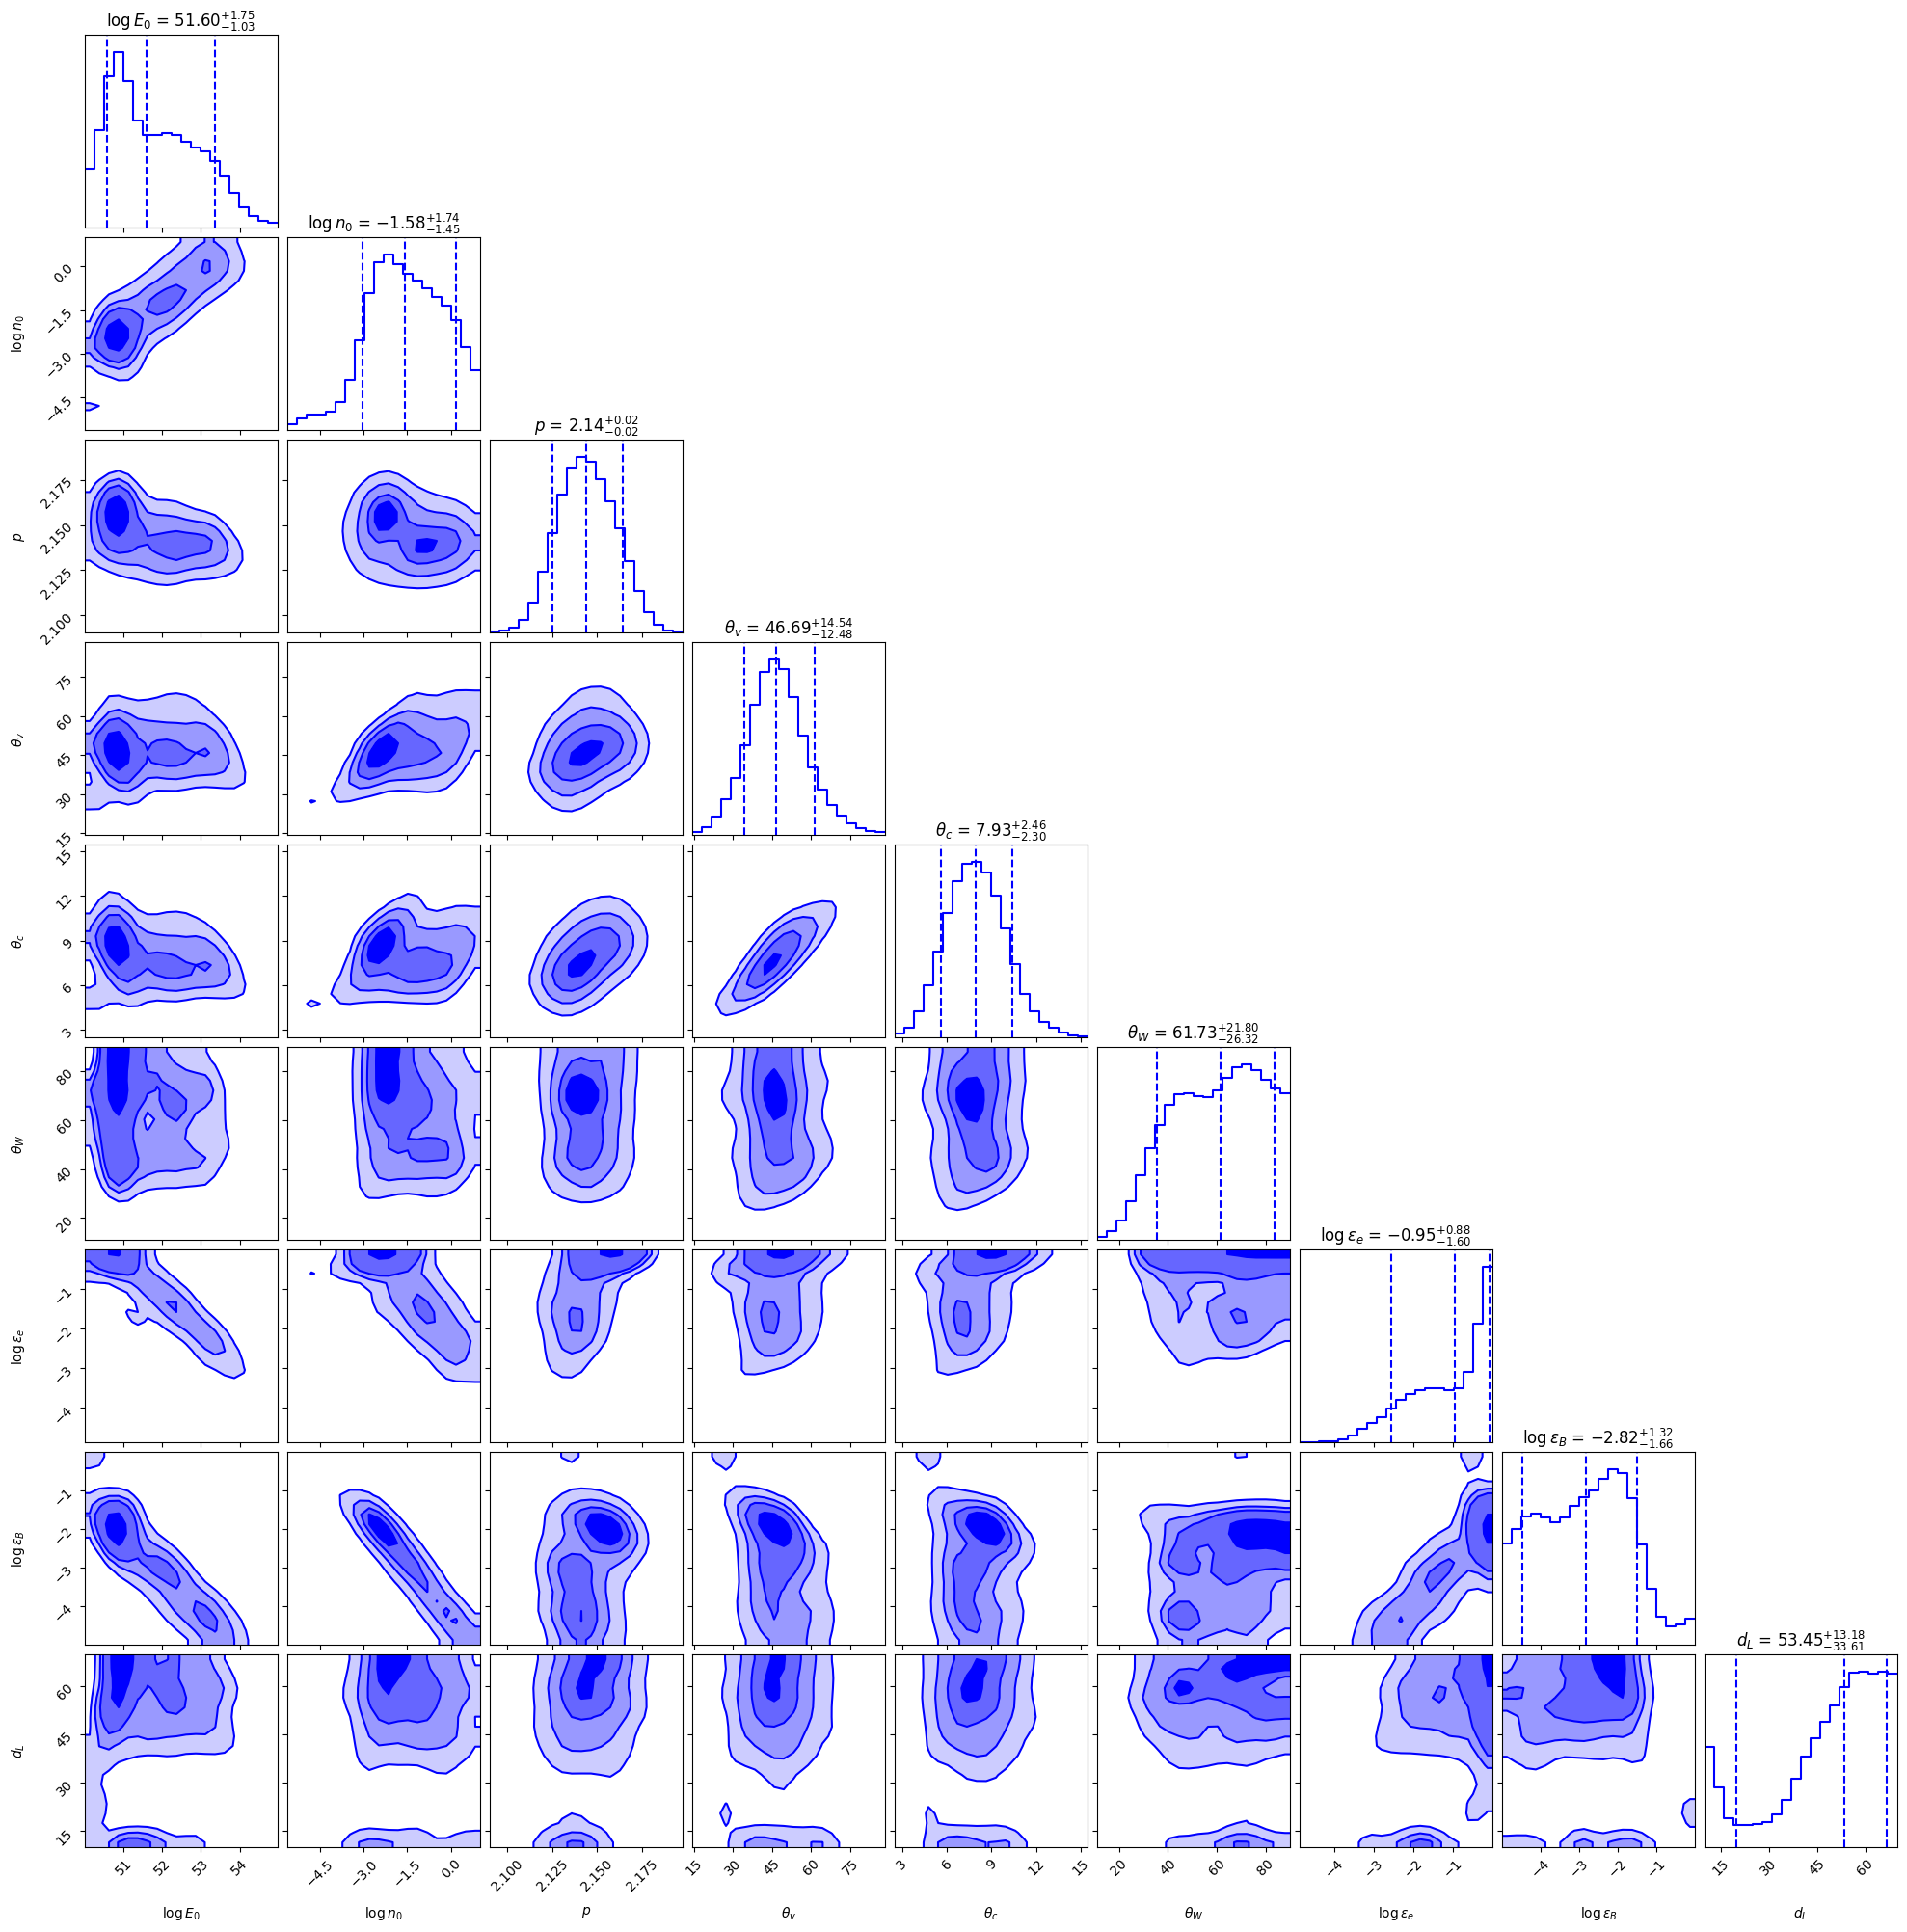

In [17]:
import corner
import numpy as np

posterior_file = './posterior.dat'  			
posterior      = np.genfromtxt(posterior_file, names=True)

fig = corner.corner(np.vstack([posterior['E0'], posterior['n0'], posterior['p'], (np.pi / 2 - np.abs(np.arccos(posterior['cos_iota']) - np.pi / 2)) * 180 / np.pi, posterior['thetaCore'] * 180 / np.pi, posterior['thetaWing'] * 180 / np.pi, posterior['epsilon_e'], posterior['epsilon_B'], posterior['distance']]).T,
            labels=[r"$\log E_0$", r"$\log n_0$", r"$p$", r"$\theta_v$", r"$\theta_c$", r"$\theta_W$", r"$\log \epsilon_e$", r"$\log \epsilon_B$", r"$d_L$"], show_titles=True, title_kwargs={"fontsize": 12},
            quantiles=[0.1, 0.5, 0.9],color='b',plot_datapoints=False,smooth=True,smooth1d=True,fill_contours=True,plot_density=True,weights=np.ones(len(posterior['E0']))*100./len(posterior['E0']),
            )